In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from array_despike import array_despike
from gaussian_fit import fit_gaussian

In [37]:
doppler_all=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_all.npy').T
velocity_sigma_all=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\velocity_sigma_all.npy').T

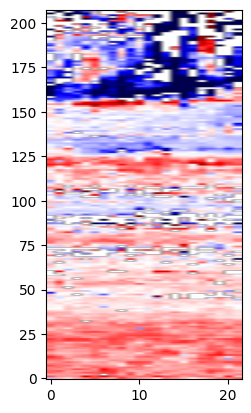

In [43]:
plt.imshow(doppler_all[12:,:]-18,cmap='seismic',origin='lower',vmin=-50,vmax=50,aspect=0.2)
#说明12以下的部分就先不用了，12的话对应65+13*3=101的位置

9.078208 0.0


Text(0.5, 1.0, 'T21:07:22')

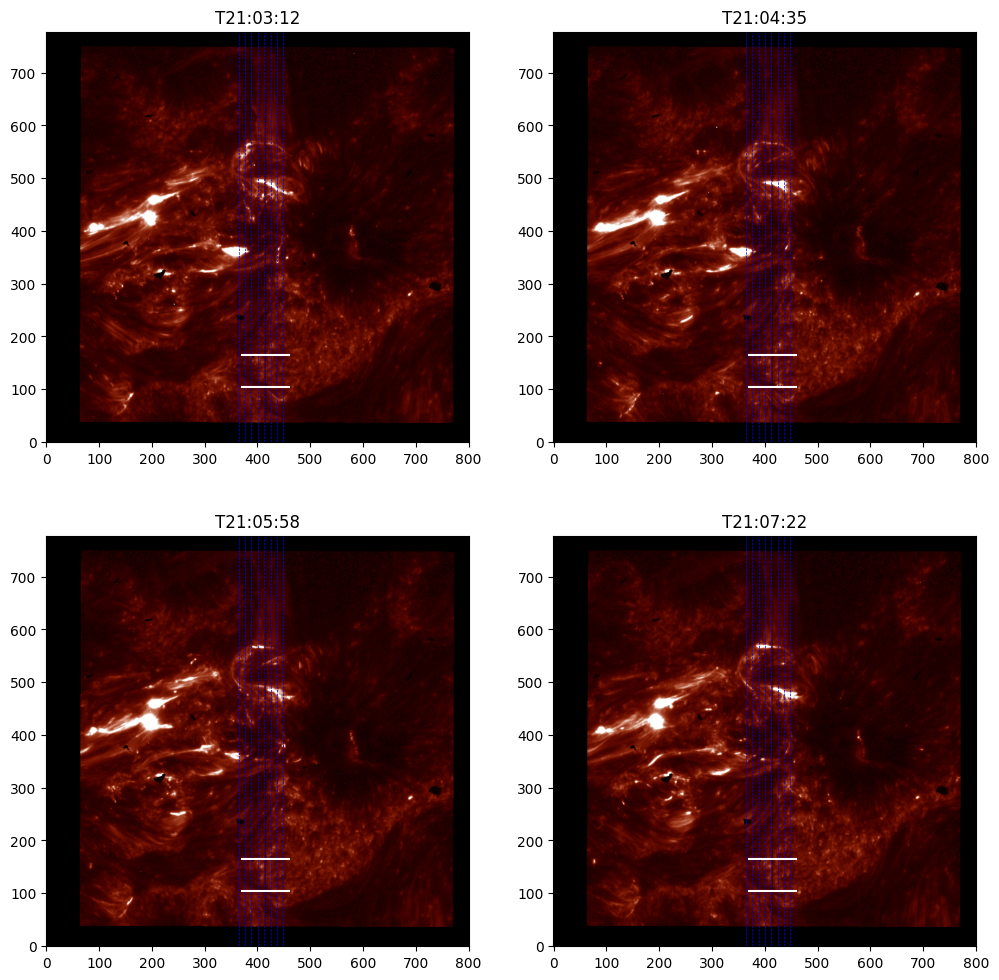

In [35]:
rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\solar_xy.sav')
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
sji1400=rsm_1400[0].data
new_map=np.log(sji1400[805,:,:]+201)#new_map=np.log(sji1400[798,:,:]+201)
print(new_map.max(),new_map.min())
fig=plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
new_map=np.log(sji1400[781,:,:]+201)
plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
for i in range(8):
    xx=(solar_x[i,0]-354.533)/0.166+400.5
    plt.axvline(xx,color='blue',linestyle='--',linewidth=0.5)
plt.plot([370, 460], [104, 104], linestyle='-', color='white')
plt.plot([370, 460], [164, 164], linestyle='-', color='white')
plt.title('T21:03:12')

plt.subplot(2,2,2)
new_map=np.log(sji1400[785,:,:]+201)
plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
for i in range(8):
    xx=(solar_x[i,0]-354.533)/0.166+400.5
    plt.axvline(xx,color='blue',linestyle='--',linewidth=0.5)
plt.plot([370, 460], [104, 104], linestyle='-', color='white')
plt.plot([370, 460], [164, 164], linestyle='-', color='white')
plt.title('T21:04:35')

plt.subplot(2,2,3)
new_map=np.log(sji1400[789,:,:]+201)
plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
for i in range(8):
    xx=(solar_x[i,0]-354.533)/0.166+400.5
    plt.axvline(xx,color='blue',linestyle='--',linewidth=0.5)
plt.plot([370, 460], [104, 104], linestyle='-', color='white')
plt.plot([370, 460], [164, 164], linestyle='-', color='white')
plt.title('T21:05:58')

plt.subplot(2,2,4)
new_map=np.log(sji1400[793,:,:]+201)
plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)
for i in range(8):
    xx=(solar_x[i,0]-354.533)/0.166+400.5
    plt.axvline(xx,color='blue',linestyle='--',linewidth=0.5)
plt.plot([370, 460], [104, 104], linestyle='-', color='white')
plt.plot([370, 460], [164, 164], linestyle='-', color='white')
plt.title('T21:07:22')

<font color=cyan>选取从781到793的，8个狭缝 x 20个空间点（每个空间点由三个Bin成）x 7个时刻 = 1120个长为165的光谱数据，用于定出参考线心</font>

In [21]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
spectra_all=np.zeros((7,8,20,40))#分别代表时间，8步扫描，空间，波长四个维度
exptime=[]
for i in range(390,397):
    rsm=fits.open(file_list[i])
    exptime.append(rsm[0].header['EXPTIME'])
    spectra=rsm[4].data[:,104:164,70:110]#我直接波长上裁剪了
    spectra=spectra.reshape(8,20,3,40)
    spectra=spectra.mean(axis=2)
    for j in range(8):
        spectrum=spectra[j,:,:]
        valid_mask = (
            np.isfinite(spectrum)
            & (spectrum != -200)
        )
        spectrum_clean, info = array_despike(
            spectrum,
            sigma=8.0,
            threshold=6.0,
            itmax=20,
            no_low=False,
            valid_mask=valid_mask,
            return_info=True,
            verbose=True,
        )
        spectra[j,:,:]=spectrum_clean
    spectra_all[i-390,:,:,:]=spectra
#spectra_all=spectra_all.reshape(7*8*20,40)

bright pass 0: replaced 1 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 2 pixels
bright pass 1: replaced 1 pixels
bright pass 2: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 2 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 2 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 4 pixels
bright pass 1: replaced 2 pixels
bright pass 2: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 1 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 1 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 1 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 1 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 2 pixels
bright pass 1: replaced 0 pi

In [23]:
from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%dT%H:%M:%S')
    time_sequence.append(time_str)

In [22]:
print(spectra_all.shape)

(7, 8, 20, 40)


In [ ]:
#准备工作
wave_x=np.arange(rsm[4].header['CRVAL1'],
                 rsm[4].header['CRVAL1']+rsm[4].header['CDELT1']*rsm[4].header['NAXIS1'],
                 rsm[4].header['CDELT1'])[70:110]
doppler_all=np.zeros((7,8,20))
lambda_all=np.zeros((7,8,20))
velocity_sigma_all=np.zeros((7,8,20))
popt_all=np.zeros((7,8,20,4))
low_snr_count, invalid_sigma_count, invalid_velocity_count=0,0,0
root_dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_fig3'

#曲线拟合
for i in range(7):
    for j in range(8):
        for k in range(20):
            wave_y=spectra_all[i,j,k,:]
            valid_fit=False
            try:
                result=fit_gaussian(wave_x,wave_y, center_guess=1402.77, positive=True)
                #筛选符合的拟合
                noise = np.nanstd(np.r_[wave_y[:8], wave_y[-8:]])
                snr = result['amplitude'] / noise
                snr_ok = snr > 1.5 #信噪比
                #snr_ok=True
                vel_ok= -200 < (result['center'] - 1402.77) / 1402.77 * 2.997e5 <200
                sigma_ok = 0.0216 < result['sigma'] < 0.3 #大于热致展宽+仪器致宽
                if not snr_ok:
                    low_snr_count += 1
                if not sigma_ok:
                    invalid_sigma_count += 1
                if not vel_ok:
                    invalid_velocity_count += 1
                valid_fit = snr_ok and sigma_ok and vel_ok

                doppler_all[i,j,k] = (result['center'] - 1402.77) / 1402.77 * 2.997e5 if valid_fit else np.nan
                lambda_all[i,j,k] = result['center'] if valid_fit else np.nan
                velocity_sigma_all[i,j,k] = result['sigma']/ 1402.77 * 2.997e5 if valid_fit else np.nan
                popt_all[i,j,k,:] = result['params'] if valid_fit else np.nan

            except:
                print(i,j,k)
                doppler_all[i,j,k]=np.nan
                lambda_all[i,j,k]=np.nan
                velocity_sigma_all[i,j,k]=np.nan
                popt_all[i,j,k,:]=np.nan
            
            plt.figure(figsize=(7,4))
            plt.step(wave_x,wave_y, label='observed')
            plt.axvline(1402.77, color='red', linestyle='--', label='rest wavelength')
            if valid_fit:
                amp, cen, sig, bg = result['params']
                wave_dense = np.linspace(wave_x.min(), wave_x.max(), 200)
                fit_dense = bg + amp * np.exp(-0.5 * ((wave_dense - cen) / sig) ** 2)
                plt.plot(wave_dense, fit_dense, label='fit')
                ax=plt.gca()
                plt.text(0.05, 0.95, f'doppler velocity: {doppler_all[i,j,k]:.4f} km/s \n sigma: {velocity_sigma_all[i,j,k]:.4f} km/s', 
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
                plt.title(f'i={i}, j={j}, SNR={snr:.2f}, sigma={result["sigma"]:.4f}')
            else:
                plt.title(f'i={i},j={j},k={k}, no valid fit')
            plt.legend()
            plt.grid()
            #plt.minorticks_on()
            plt.savefig(os.path.join(root_dir, f'IRIS_{i}_{j}_{k}.png'))
            plt.close()
print(f'low_snr_count: {low_snr_count}')
print(f'invalid_sigma_count: {invalid_sigma_count}')
print(f'invalid_velocity_count: {invalid_velocity_count}')

low_snr_count: 8
invalid_sigma_count: 18


In [33]:
print(np.nanmean(lambda_all))

1402.895558612604


In [34]:
print((1402.89555-1402.77)/1402.77*2.997e5)

26.823595457553765


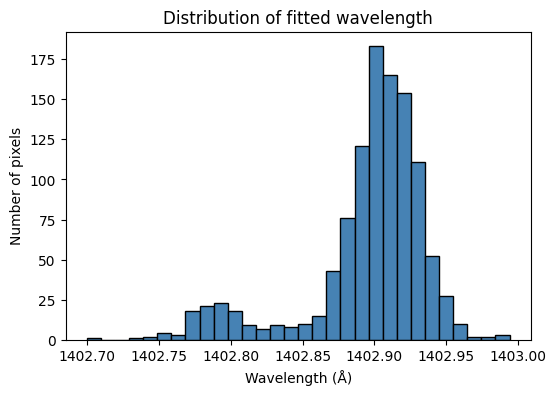

In [47]:
lambda_valid = lambda_all[np.isfinite(lambda_all)]
plt.figure(figsize=(6, 4))
plt.hist(lambda_valid, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Number of pixels')
plt.title('Distribution of fitted wavelength')
plt.show()

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from gaussian_fit import fit_gaussian

lambda0 = 1402.90

lambda_valid = lambda_all[np.isfinite(lambda_all)]

counts, bin_edges = np.histogram(lambda_valid, bins=40)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

result = fit_gaussian(
    bin_centers,
    counts,
    center_guess=lambda0,
    positive=True
)

center_fit = result['center']
sigma_fit = result['sigma']

print('Histogram Gaussian center =', center_fit, 'Å')
print('Histogram Gaussian sigma =', sigma_fit, 'Å')

doppler_v = (center_fit - 1402.77) / 1402.77 * 2.997e5
print('Mean Doppler velocity =', doppler_v, 'km/s')

Histogram Gaussian center = 1402.908537265435 Å
Histogram Gaussian sigma = 0.020496677801038154 Å
Mean Doppler velocity = 29.59830795558053 km/s


Text(0.2, 0.6, 'Doppler velocity: 29.60km/s')

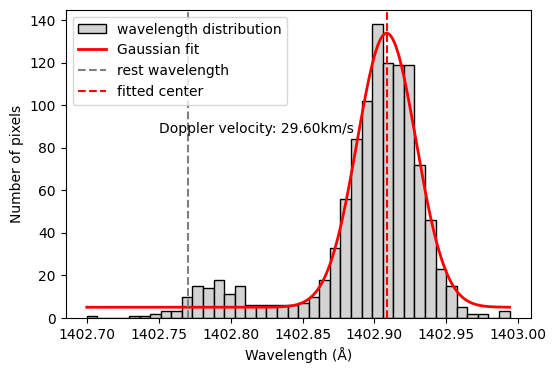

In [89]:
amp, cen, sig, bg = result['params']

x_dense = np.linspace(bin_edges[0], bin_edges[-1], 1000)

fit_dense = bg + amp * np.exp(
    -0.5 * ((x_dense - cen) / sig) ** 2
)

plt.figure(figsize=(6, 4))

plt.hist(
    lambda_valid,
    bins=bin_edges,
    color='lightgray',
    edgecolor='black',
    label='wavelength distribution'
)

plt.plot(
    x_dense,
    fit_dense,
    color='red',
    linewidth=2,
    label='Gaussian fit'
)

plt.axvline(1402.77, color='gray', linestyle='--', label='rest wavelength')
plt.axvline(cen, color='red', linestyle='--', label='fitted center')

plt.xlabel('Wavelength (Å)')
plt.ylabel('Number of pixels')
plt.legend()
plt.text(0.2,0.6,'Doppler velocity: 29.60km/s',transform=plt.gca().transAxes)

Text(0.5, 1.0, 'Si IV Doppler Shift')

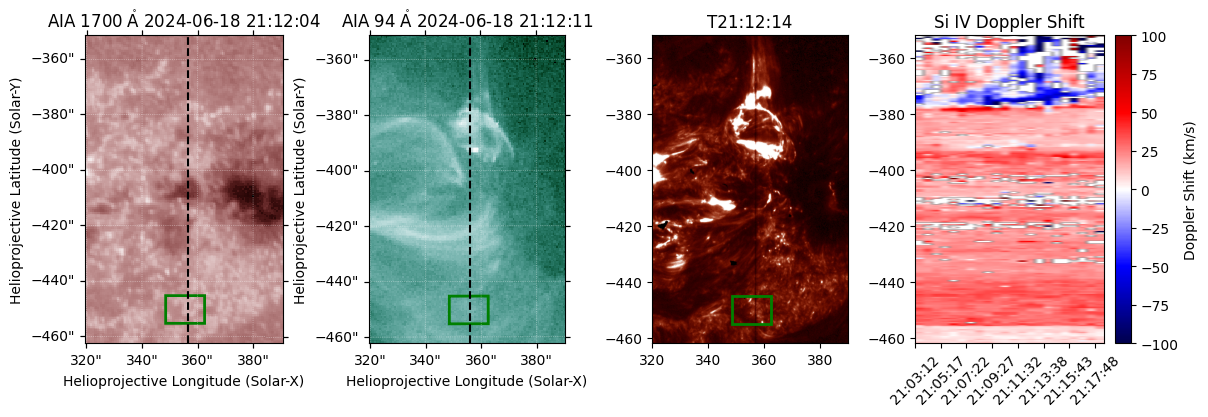

In [73]:
doppler_all_raw=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_all.npy')
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\solar_xy.sav')
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
all_sji_image=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']

from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%dT%H:%M:%S')
    time_sequence.append(time_str)
time_x=time_sequence[781:825:2]
time_xx=[dt[-8:] for dt in time_x]

fig=plt.figure(figsize=(14,4))
gs=gridspec.GridSpec(1,4)

aia1700=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\1700\aia.lev1_uv_24s.2024-06-18T211205Z.1700.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
aia1700_sub=aia1700.submap(bottom_left=bottom_left, top_right=top_right)
ax0=fig.add_subplot(gs[0],projection=aia1700_sub)
image = aia1700_sub.plot(axes=ax0)
coord = SkyCoord(
    solar_x[4, 0] * u.arcsec,
    0 * u.arcsec,
    frame=aia1700_sub.coordinate_frame
)
x_pixel, _ = aia1700_sub.world_to_pixel(coord)
ax0.axvline(x=x_pixel.value, color="black", linestyle="--")
coord1=SkyCoord(solar_x[0,0]*u.arcsec,solar_y[104,0]*u.arcsec,frame=aia1700_sub.coordinate_frame)
coord2=SkyCoord(solar_x[7,0]*u.arcsec,solar_y[164,0]*u.arcsec,frame=aia1700_sub.coordinate_frame)
aia1700_sub.draw_quadrangle(coord1,top_right=coord2,edgecolor='green',linewidth=2)

aia94=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\.94\aia.lev1_euv_12s.2024-06-18T211213Z.94.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
aia94_sub=aia94.submap(bottom_left=bottom_left, top_right=top_right)
ax1=fig.add_subplot(gs[1],projection=aia94_sub)
image = aia94_sub.plot(axes=ax1)
ax1.axvline(x=x_pixel.value, color="black", linestyle="--")
aia94.draw_quadrangle(coord1,top_right=coord2,edgecolor='green',linewidth=2)

ax2=fig.add_subplot(gs[2])
ax2.imshow(all_sji_image[807][0][:,:],cmap='irissji1400',vmin=0,vmax=20,origin='lower',
	extent=[320,320+422*0.166,-407-332*0.166,-407+332*0.166])
ax2.set_title('T21:12:14')
from matplotlib.patches import Rectangle
# 第一幅图绿色框对应的太阳坐标范围
x0 = solar_x[0, 0]
x1 = solar_x[7, 0]
y0 = solar_y[104, 0]
y1 = solar_y[164, 0]
ax2.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor='green', linewidth=2))


ax3=fig.add_subplot(gs[3])
ax3.imshow(doppler_all_raw.T,cmap='seismic',vmin=-100,vmax=100,origin='lower',
           aspect='auto',extent=[0,22,-407-332*0.166,-407+332*0.166])
cbar=ax3.figure.colorbar(ax3.images[0],ax=ax3)
cbar.set_label('Doppler Shift (km/s)')
ax3.set_xticks(range(0, 22, 3))
ax3.set_xticklabels(time_xx[::3],rotation=45)
ax3.set_title('Si IV Doppler Shift')



In [60]:
print(solar_x.shape,solar_y.shape)

(8, 4) (778, 4)


In [61]:
print(solar_x)

[[348.52682 348.90842 348.97903 350.71634]
 [350.52396 350.9074  350.9804  352.7144 ]
 [352.52826 352.905   352.97797 354.76453]
 [354.53348 354.89755 354.97202 356.76328]
 [356.57254 356.94183 357.0189  358.75543]
 [358.56033 358.94122 359.01797 360.74878]
 [360.5557  360.9361  361.0174  362.74686]
 [362.5513  362.9239  363.01697 364.79388]]


In [62]:
print(solar_y[0,:])

[-472.57297 -472.64096 -472.63498 -472.73297]


In [63]:
print(solar_y[0:4,:])

[[-472.57297 -472.64096 -472.63498 -472.73297]
 [-472.40662 -472.47464 -472.46863 -472.56662]
 [-472.24026 -472.3083  -472.30228 -472.40027]
 [-472.0739  -472.14194 -472.13593 -472.23392]]


In [90]:
data = np.load('doppler_sigma_velocity.npz')
doppler_vel = data['doppler_vel']
sigma_vel = data['sigma_vel']

In [132]:
#----------------------------------------------------------------------------------------------


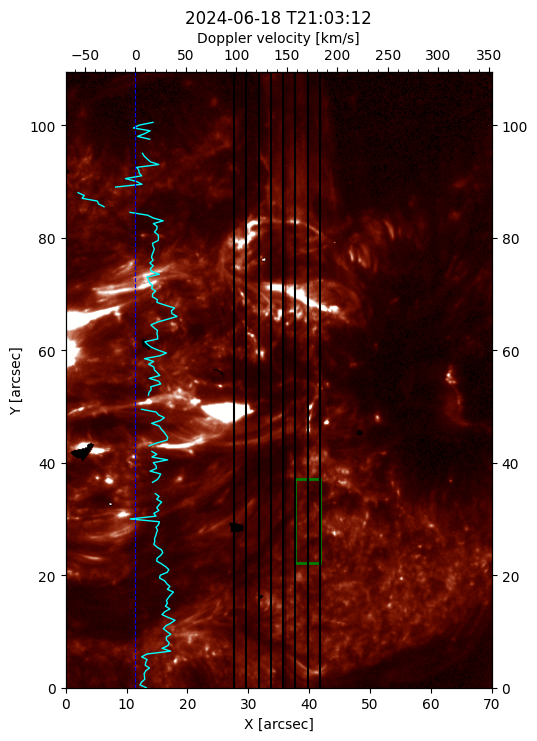

In [ ]:
data1 = all_sji_image[781][0]  # 第一组数据 (402x660)
doppler_all=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_all.npy').T
data2 = doppler_all[:,0].copy()  # 第二组数据 (长度220)
data2[data2>200]=np.nan
data2[data2<-200]=np.nan
# 创建画布
fig, left_ax = plt.subplots(figsize=(5.5,8))  

# 左侧：imshow 画 402x660 矩阵（转换为角秒单位）
im = left_ax.imshow(data1, aspect='auto', cmap='irissji1400', origin='lower', 
                    vmin=0, vmax=23,extent=[0, 422*0.166, 0, 660*0.166])  # 关键修改：设置坐标范围为角秒)
left_ax.set_xlabel("X [arcsec]")  # 修改x轴标签
left_ax.set_ylabel("Y [arcsec]")  # 修改y轴标签

# 计算坐标偏移量（转换为角秒单位）
offset_pixel = (348.04 - 320)/0.166-100#这里其实应该减320但可能是画图的问题，减321才能对齐狭缝
offset_arcsec = offset_pixel * 0.166  # 像素转角秒
# 右侧：创建共享Y轴的新轴
right_ax = left_ax.twinx()
y_vals = np.linspace(0, 660*0.166, 220)  # 转换为角秒坐标
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_solar_xy.sav')
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
kx=390
for i in range(8):
    left_ax.axvline(x=(solar_x[i,kx]-320),color='black',linestyle='-')

x0=solar_x[5,kx]-320#320和-462是图像的左下角
x1=solar_x[7,kx]-320
y0=solar_y[197,kx]+462
y1=solar_y[287,kx]+462
left_ax.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor='green', linewidth=2))
# 绘制调整后的data2（x坐标转换为角秒）
converted_data2 = data2 * 0.166 + offset_arcsec  # 关键修改：data2值转角秒
right_ax.plot(converted_data2, y_vals, color='cyan', linestyle='-', linewidth=1)
left_ax.set_xlim(0, 422*0.166)
right_ax.set_xlim(0, 422*0.166)
right_ax.set_title('2024-06-18 T21:03:12')
# 设置右侧次级x轴转换函数（处理角秒单位）
def data2_transform(x_arcsec):
    """将绘图坐标（角秒）转换回原始data2值"""
    return (x_arcsec - offset_arcsec) / 0.166

def inv_data2_transform(data2_val):
    """将原始data2值转换为绘图坐标（角秒）"""
    return data2_val * 0.166 + offset_arcsec

# 创建右侧x轴并设置标签
secax = right_ax.secondary_xaxis('top', functions=(data2_transform, inv_data2_transform))
secax.set_xlabel('Doppler velocity [km/s]')
#secax.axvline(0, color='gray', linestyle='--', alpha=0.5)
secax.minorticks_on()
zero_pos=inv_data2_transform(0)
right_ax.axvline(x=zero_pos,color='blue',linestyle='--',linewidth=0.8)
# 同步Y轴范围
right_ax.set_ylim(left_ax.get_ylim())

# 隐藏右侧多余的Y轴
#right_ax.yaxis.set_visible(False)

plt.show()


<font color=cyan>选取从781到793的，6/7/8三个个狭缝 x solar_y[197:287]30个空间点（每个空间点由三个Bin成）x 7个时刻 = 630个长为165的光谱数据，用于定出参考线心</font>

In [158]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
spectra_all=np.zeros((7,3,30,40))#分别代表时间，8步扫描，空间，波长四个维度
exptime=[]
for i in range(390,397):
    rsm=fits.open(file_list[i])
    exptime.append(rsm[0].header['EXPTIME'])
    spectra=rsm[4].data[5:,197:287,70:110]#我直接波长上裁剪了
    spectra=spectra.reshape(3,30,3,40)
    spectra=spectra.mean(axis=2)
    for j in range(3):
        spectrum=spectra[j,:,:]
        valid_mask = (
            np.isfinite(spectrum)
            & (spectrum != -200)
        )
        spectrum_clean, info = array_despike(
            spectrum,
            sigma=8.0,
            threshold=6.0,
            itmax=20,
            no_low=False,
            valid_mask=valid_mask,
            return_info=True,
            verbose=True,
        )
        spectra[j,:,:]=spectrum_clean
    spectra_all[i-390,:,:,:]=spectra

bright pass 0: replaced 2 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 5 pixels
bright pass 1: replaced 4 pixels
bright pass 2: replaced 3 pixels
bright pass 3: replaced 3 pixels
bright pass 4: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark pass 0: replaced 1 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark pass 0: replaced 1 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark pass 0: replaced 1 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 1 pixels
bright pass 1: replaced 0 pixels
dark pass 0: replaced 1 pixels
dark pass 1: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark pass 0: replaced 0 pixels
bright pass 0: replaced 0 pixels
dark 

In [159]:
#准备工作
wave_x=np.arange(rsm[4].header['CRVAL1'],
                 rsm[4].header['CRVAL1']+rsm[4].header['CDELT1']*rsm[4].header['NAXIS1'],
                 rsm[4].header['CDELT1'])[70:110]
doppler_all=np.zeros((7,3,30))
lambda_all=np.zeros((7,3,30))
velocity_sigma_all=np.zeros((7,3,30))
popt_all=np.zeros((7,3,30,4))
low_snr_count, invalid_sigma_count, invalid_velocity_count=0,0,0
root_dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\all_time_fig_quiet2'

#曲线拟合
for i in range(7):
    for j in range(3):
        for k in range(30):
            wave_y=spectra_all[i,j,k,:]
            valid_fit=False
            try:
                result=fit_gaussian(wave_x,wave_y, center_guess=1402.77, positive=True)
                #筛选符合的拟合
                noise = np.nanstd(np.r_[wave_y[:8], wave_y[-8:]])
                snr = result['amplitude'] / noise
                snr_ok = snr > 1.5 #信噪比
                #snr_ok=True
                vel_ok= -200 < (result['center'] - 1402.77) / 1402.77 * 2.997e5 <200

                sigma_ok = 0.0216 < result['sigma'] < 0.3 #大于热致展宽+仪器致宽
                if not snr_ok:
                    low_snr_count += 1
                if not sigma_ok:
                    invalid_sigma_count += 1
                if not vel_ok:
                    invalid_velocity_count += 1
                valid_fit = snr_ok and sigma_ok and vel_ok

                doppler_all[i,j,k] = (result['center'] - 1402.77) / 1402.77 * 2.997e5 if valid_fit else np.nan
                lambda_all[i,j,k] = result['center'] if valid_fit else np.nan
                velocity_sigma_all[i,j,k] = result['sigma']/ 1402.77 * 2.997e5 if valid_fit else np.nan
                popt_all[i,j,k,:] = result['params'] if valid_fit else np.nan

            except:
                print(i,j,k)
                doppler_all[i,j,k]=np.nan
                lambda_all[i,j,k]=np.nan
                velocity_sigma_all[i,j,k]=np.nan
                popt_all[i,j,k,:]=np.nan
            
            plt.figure(figsize=(7,4))
            plt.step(wave_x,wave_y, label='observed')
            plt.axvline(1402.77, color='red', linestyle='--', label='rest wavelength')
            if valid_fit:
                amp, cen, sig, bg = result['params']
                wave_dense = np.linspace(wave_x.min(), wave_x.max(), 200)
                fit_dense = bg + amp * np.exp(-0.5 * ((wave_dense - cen) / sig) ** 2)
                plt.plot(wave_dense, fit_dense, label='fit')
                ax=plt.gca()
                plt.text(0.05, 0.95, f'doppler velocity: {doppler_all[i,j,k]:.4f} km/s \n sigma: {velocity_sigma_all[i,j,k]:.4f} km/s', 
                    transform=ax.transAxes, fontsize=10, verticalalignment='top')
                plt.title(f'i={i}, j={j}, SNR={snr:.2f}, sigma={result["sigma"]:.4f}')
            else:
                plt.title(f'i={i},j={j},k={k}, no valid fit')
            plt.legend()
            plt.grid()
            #plt.minorticks_on()
            plt.savefig(os.path.join(root_dir, f'IRIS_{i}_{j}_{k}.png'))
            plt.close()
print(f'low_snr_count: {low_snr_count}')
print(f'invalid_sigma_count: {invalid_sigma_count}')
print(f'invalid_velocity_count: {invalid_velocity_count}')

low_snr_count: 1
invalid_sigma_count: 5
invalid_velocity_count: 1


In [176]:
print((np.nanmean(lambda_valid)-1402.77)/1402.77*2.997e5)

24.363437637397972


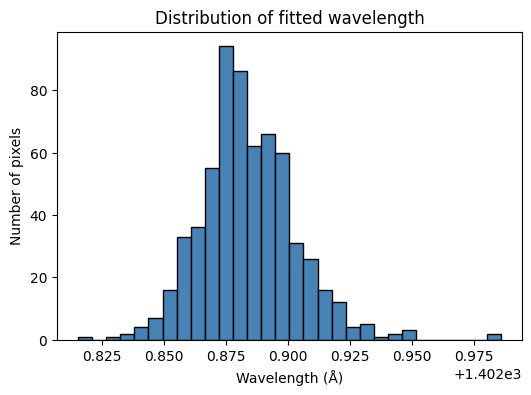

In [160]:
lambda_valid = lambda_all[np.isfinite(lambda_all)]
plt.figure(figsize=(6, 4))
plt.hist(lambda_valid, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Wavelength (Å)')
plt.ylabel('Number of pixels')
plt.title('Distribution of fitted wavelength')
plt.show()

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from gaussian_fit import fit_gaussian

lambda0 = 1402.875

lambda_valid = lambda_all[np.isfinite(lambda_all)]

counts, bin_edges = np.histogram(lambda_valid, bins=40)

bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

result = fit_gaussian(
    bin_centers,
    counts,
    center_guess=lambda0,
    positive=True
)

center_fit = result['center']
sigma_fit = result['sigma']

print('Histogram Gaussian center =', center_fit, 'Å')
print('Histogram Gaussian sigma =', sigma_fit, 'Å')

doppler_v = (center_fit - 1402.77) / 1402.77 * 2.997e5
half_width_vel=np.sqrt(2*np.log(2))*sigma_fit/1402.77*2.997e5
print('Mean Doppler velocity =', doppler_v, 'km/s')
print('Half width Doppler velocity =', half_width_vel, 'km/s')



Histogram Gaussian center = 1402.8820605592957 Å
Histogram Gaussian sigma = 0.01646078736980224 Å
Mean Doppler velocity = 23.941593861384124 km/s
Half width Doppler velocity = 4.140746151900937 km/s


Text(0.83, 0.65, '=4.14km/s')

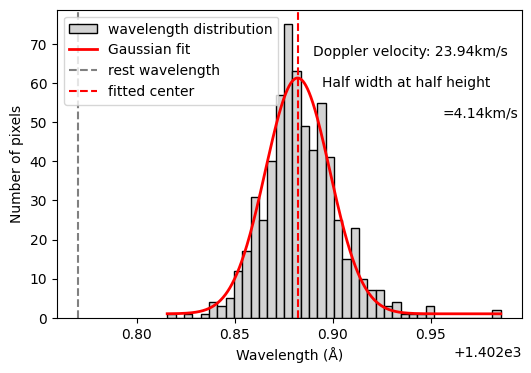

In [171]:
amp, cen, sig, bg = result['params']

x_dense = np.linspace(bin_edges[0], bin_edges[-1], 1000)

fit_dense = bg + amp * np.exp(
    -0.5 * ((x_dense - cen) / sig) ** 2
)

plt.figure(figsize=(6, 4))

plt.hist(
    lambda_valid,
    bins=bin_edges,
    color='lightgray',
    edgecolor='black',
    label='wavelength distribution'
)

plt.plot(
    x_dense,
    fit_dense,
    color='red',
    linewidth=2,
    label='Gaussian fit'
)

plt.axvline(1402.77, color='gray', linestyle='--', label='rest wavelength')
plt.axvline(cen, color='red', linestyle='--', label='fitted center')

plt.xlabel('Wavelength (Å)')
plt.ylabel('Number of pixels')
plt.legend()
plt.text(0.55,0.85,'Doppler velocity: 23.94km/s',transform=plt.gca().transAxes)
plt.text(0.57,0.75,'Half width at half height', transform=plt.gca().transAxes)
plt.text(0.83,0.65,'=%.2fkm/s'%half_width_vel,transform=plt.gca().transAxes)

Text(0.5, 1.0, 'Corrected Si IV Doppler Shift')

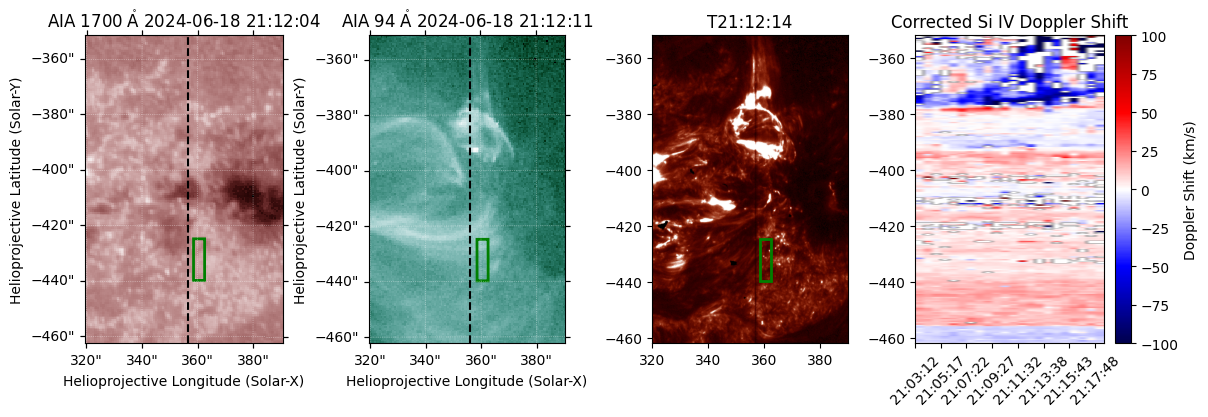

In [178]:
doppler_all_raw=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\doppler_all.npy')
solar_xy=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\solar_xy.sav')
solar_x=solar_xy['solar_x']
solar_y=solar_xy['solar_y']
all_sji_image=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data_process\all_sji_image.sav')['matrix_struct']

from datetime import datetime, timedelta

# 定义起始时间
start_time = datetime.fromisoformat('2024-06-18T16:31:42')
# 定义每次增加的时间间隔
interval = timedelta(seconds=20.8583)

# 生成时间序列
time_sequence = []
for i in range(990):
    current_time = start_time + i * interval
    # 格式化时间为只显示到秒
    time_str = current_time.strftime('%Y-%m-%dT%H:%M:%S')
    time_sequence.append(time_str)
time_x=time_sequence[781:825:2]
time_xx=[dt[-8:] for dt in time_x]

fig=plt.figure(figsize=(14,4))
gs=gridspec.GridSpec(1,4)

aia1700=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\1700\aia.lev1_uv_24s.2024-06-18T211205Z.1700.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia1700.coordinate_frame)
aia1700_sub=aia1700.submap(bottom_left=bottom_left, top_right=top_right)
ax0=fig.add_subplot(gs[0],projection=aia1700_sub)
image = aia1700_sub.plot(axes=ax0)
coord = SkyCoord(
    solar_x[4, 0] * u.arcsec,
    0 * u.arcsec,
    frame=aia1700_sub.coordinate_frame
)
x_pixel, _ = aia1700_sub.world_to_pixel(coord)
ax0.axvline(x=x_pixel.value, color="black", linestyle="--")
coord1=SkyCoord(solar_x[5,0]*u.arcsec,solar_y[197,0]*u.arcsec,frame=aia1700_sub.coordinate_frame)
coord2=SkyCoord(solar_x[7,0]*u.arcsec,solar_y[287,0]*u.arcsec,frame=aia1700_sub.coordinate_frame)
aia1700_sub.draw_quadrangle(coord1,top_right=coord2,edgecolor='green',linewidth=2)

aia94=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\.94\aia.lev1_euv_12s.2024-06-18T211213Z.94.image_lev1.fits')
bottom_left=SkyCoord(320*u.arcsec,(-407-332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
top_right=SkyCoord((320+422*0.166)*u.arcsec,(-407+332*0.166)*u.arcsec,frame=aia94.coordinate_frame)
aia94_sub=aia94.submap(bottom_left=bottom_left, top_right=top_right)
ax1=fig.add_subplot(gs[1],projection=aia94_sub)
image = aia94_sub.plot(axes=ax1)
ax1.axvline(x=x_pixel.value, color="black", linestyle="--")
aia94.draw_quadrangle(coord1,top_right=coord2,edgecolor='green',linewidth=2)

ax2=fig.add_subplot(gs[2])
ax2.imshow(all_sji_image[807][0][:,:],cmap='irissji1400',vmin=0,vmax=20,origin='lower',
	extent=[320,320+422*0.166,-407-332*0.166,-407+332*0.166])
ax2.set_title('T21:12:14')
from matplotlib.patches import Rectangle
# 第一幅图绿色框对应的太阳坐标范围
x0 = solar_x[5, 0]
x1 = solar_x[7, 0]
y0 = solar_y[197, 0]
y1 = solar_y[287, 0]
ax2.add_patch(Rectangle((x0, y0), x1-x0, y1-y0, fill=False, edgecolor='green', linewidth=2))


ax3=fig.add_subplot(gs[3])
ax3.imshow(doppler_all_raw.T-15.87,cmap='seismic',vmin=-100,vmax=100,origin='lower',
           aspect='auto',extent=[0,22,-407-332*0.166,-407+332*0.166])
cbar=ax3.figure.colorbar(ax3.images[0],ax=ax3)
cbar.set_label('Doppler Shift (km/s)')
ax3.set_xticks(range(0, 22, 3))
ax3.set_xticklabels(time_xx[::3],rotation=45)
ax3.set_title('Corrected Si IV Doppler Shift')

